## Introduction
This notebook demonstrates the classification of pumpkin seed varieties using dimensionality reduction techniques (PCA and Kernel PCA) combined with machine learning models. The dataset contains morphological measurements of two pumpkin seed varieties: "Urgup_Sivrisi" and "Cercevelik".

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA, KernelPCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


# Data Loading and Exploration

In [2]:
# Load the dataset
seed = pd.read_csv('Pumpkin_Seeds_Dataset.csv')

In [3]:
# Convert only numeric columns (skip the Class column)
for col in seed.columns:
    if col != 'Class' and seed[col].dtype == object:
        # Only replace commas in numeric columns
        seed[col] = seed[col].str.replace(',', '', regex=False)
        seed[col] = pd.to_numeric(seed[col], errors='coerce')

In [4]:
# Check data information
seed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               2500 non-null   int64  
 1   Perimeter          2500 non-null   float64
 2   Major_Axis_Length  2500 non-null   float64
 3   Minor_Axis_Length  2500 non-null   float64
 4   Convex_Area        2500 non-null   int64  
 5   Equiv_Diameter     2500 non-null   float64
 6   Eccentricity       2500 non-null   float64
 7   Solidity           2500 non-null   float64
 8   Extent             2500 non-null   float64
 9   Roundness          2500 non-null   float64
 10  Aspect_Ration      2500 non-null   float64
 11  Compactness        2500 non-null   float64
 12  Class              2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 254.0+ KB


In [5]:
# Check for null values
seed.isnull().sum()

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Convex_Area          0
Equiv_Diameter       0
Eccentricity         0
Solidity             0
Extent               0
Roundness            0
Aspect_Ration        0
Compactness          0
Class                0
dtype: int64

In [6]:
# Check class distribution
print("\nClass Distribution:")
print(seed['Class'].value_counts())


Class Distribution:
Class
Çerçevelik       1300
Ürgüp Sivrisi    1200
Name: count, dtype: int64


# Data Preparation

In [7]:
# Separate features and target
X = seed.drop('Class', axis=1)
y = seed['Class']



In [8]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Training set shape: (1750, 12)
Test set shape: (750, 12)


# Dimensionality Reduction

# Standard PCA with Pipeline

In [9]:
# Create PCA pipeline with StandardScaler
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95))  # Retain 95% of variance
])

# Fit and transform the training data
X_train_pca = pca_pipeline.fit_transform(X_train)

# Transform the test data using the same pipeline
X_test_pca = pca_pipeline.transform(X_test)

# Check number of components selected
n_components = pca_pipeline.named_steps['pca'].n_components_
print(f"\nNumber of PCA components retained: {n_components}")
print(f"Explained variance ratio: {pca_pipeline.named_steps['pca'].explained_variance_ratio_.sum():.2f}")


Number of PCA components retained: 4
Explained variance ratio: 0.99


# PCA Cumulative Explained Variance Plot         

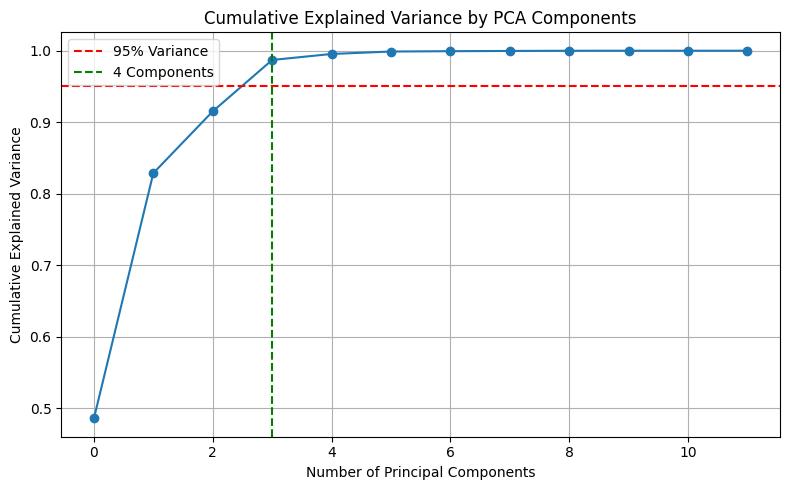

In [10]:
# Plot cumulative explained variance
pca = PCA()
pca.fit(StandardScaler().fit_transform(X_train))  # Fit on scaled training data

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axvline(x=np.argmax(cumulative_variance >= 0.95), color='g', linestyle='--',
            label=f'{np.argmax(cumulative_variance >= 0.95)+1} Components')
plt.legend()
plt.tight_layout()
plt.show()


# Kernel PCA with Pipeline

In [11]:
# Create Kernel PCA pipeline with StandardScaler
kpca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kpca', KernelPCA(n_components=5, kernel='rbf', fit_inverse_transform=True, random_state=42))
])

# Fit and transform the training data
X_train_kpca = kpca_pipeline.fit_transform(X_train)

# Transform the test data using the same pipeline
X_test_kpca = kpca_pipeline.transform(X_test)

print("\nKernel PCA transformation complete")


Kernel PCA transformation complete


## Model Training with PCA

# SVM with PCA and GridSearchCV


Training SVM with PCA...
Best SVM with PCA parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM with PCA CV score: 0.8760

Classification Report for SVM with PCA:
               precision    recall  f1-score   support

   Çerçevelik       0.86      0.92      0.89       410
Ürgüp Sivrisi       0.90      0.81      0.85       340

     accuracy                           0.87       750
    macro avg       0.88      0.87      0.87       750
 weighted avg       0.87      0.87      0.87       750

Test Accuracy for SVM with PCA: 0.8720


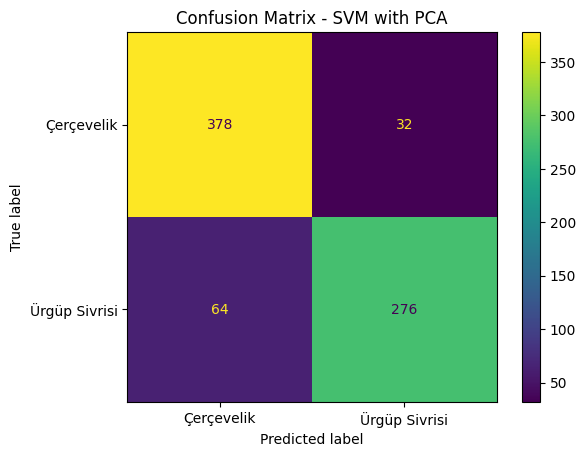

In [12]:
# Define SVM model and parameters
svm_pca = SVC()
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

# GridSearchCV for SVM with PCA
print("\nTraining SVM with PCA...")
grid_svm_pca = GridSearchCV(svm_pca, svm_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm_pca.fit(X_train_pca, y_train)

# Best parameters and score
print("Best SVM with PCA parameters:", grid_svm_pca.best_params_)
print("Best SVM with PCA CV score: {:.4f}".format(grid_svm_pca.best_score_))

# Evaluate on test set
y_pred_svm_pca = grid_svm_pca.predict(X_test_pca)
print("\nClassification Report for SVM with PCA:")
print(classification_report(y_test, y_pred_svm_pca))
print("Test Accuracy for SVM with PCA: {:.4f}".format(accuracy_score(y_test, y_pred_svm_pca)))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_svm_pca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_svm_pca.classes_)
disp.plot()
plt.title('Confusion Matrix - SVM with PCA')
plt.show()


# Random Forest with PCA and GridSearchCV


Training Random Forest with PCA...
Best RF with PCA parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best RF with PCA CV score: 0.8777

Classification Report for Random Forest with PCA:
               precision    recall  f1-score   support

   Çerçevelik       0.85      0.91      0.88       410
Ürgüp Sivrisi       0.89      0.81      0.84       340

     accuracy                           0.87       750
    macro avg       0.87      0.86      0.86       750
 weighted avg       0.87      0.87      0.86       750

Test Accuracy for Random Forest with PCA: 0.8653


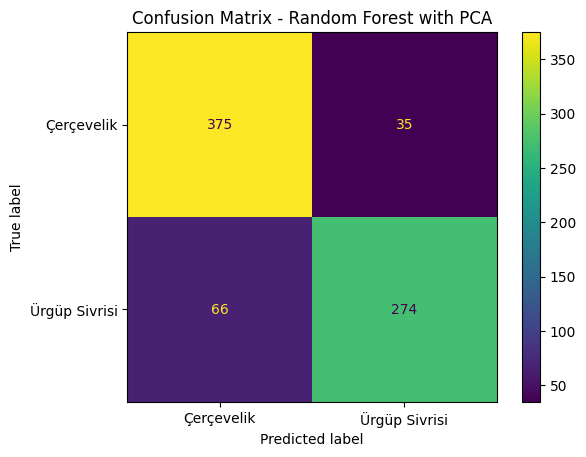

In [20]:
# Define Random Forest model and parameters
rf_pca = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV for RF with PCA
print("\nTraining Random Forest with PCA...")
grid_rf_pca = GridSearchCV(rf_pca, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf_pca.fit(X_train_pca, y_train)

# Best parameters and score
print("Best RF with PCA parameters:", grid_rf_pca.best_params_)
print("Best RF with PCA CV score: {:.4f}".format(grid_rf_pca.best_score_))

# Evaluate on test set
y_pred_rf_pca = grid_rf_pca.predict(X_test_pca)
print("\nClassification Report for Random Forest with PCA:")
print(classification_report(y_test, y_pred_rf_pca))
print("Test Accuracy for Random Forest with PCA: {:.4f}".format(accuracy_score(y_test, y_pred_rf_pca)))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_rf_pca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_rf_pca.classes_)
disp.plot()
plt.title('Confusion Matrix - Random Forest with PCA')
plt.show()


# Model Training with Kernel PCA
# SVM with Kernel PCA and GridSearchCV


Training SVM with Kernel PCA...
Best SVM with Kernel PCA parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best SVM with Kernel PCA CV score: 0.8737

Classification Report for SVM with Kernel PCA:
               precision    recall  f1-score   support

   Çerçevelik       0.85      0.92      0.88       410
Ürgüp Sivrisi       0.89      0.81      0.85       340

     accuracy                           0.87       750
    macro avg       0.87      0.86      0.86       750
 weighted avg       0.87      0.87      0.87       750

Test Accuracy for SVM with Kernel PCA: 0.8667


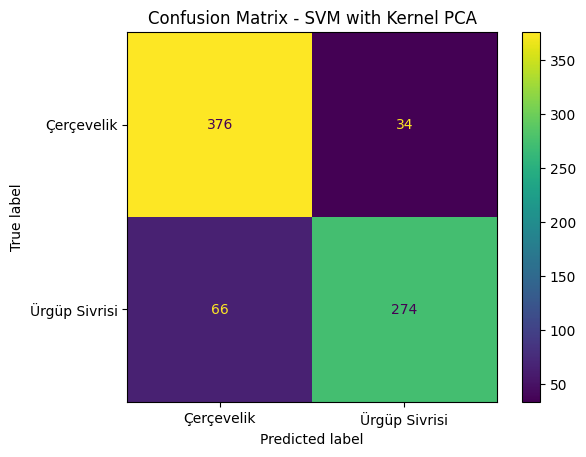

In [21]:
# Define SVM model and parameters for Kernel PCA
svm_kpca = SVC()
svm_kpca_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

# GridSearchCV for SVM with Kernel PCA
print("\nTraining SVM with Kernel PCA...")
grid_svm_kpca = GridSearchCV(svm_kpca, svm_kpca_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm_kpca.fit(X_train_kpca, y_train)

# Best parameters and score
print("Best SVM with Kernel PCA parameters:", grid_svm_kpca.best_params_)
print("Best SVM with Kernel PCA CV score: {:.4f}".format(grid_svm_kpca.best_score_))

# Evaluate on test set
y_pred_svm_kpca = grid_svm_kpca.predict(X_test_kpca)
print("\nClassification Report for SVM with Kernel PCA:")
print(classification_report(y_test, y_pred_svm_kpca))
print("Test Accuracy for SVM with Kernel PCA: {:.4f}".format(accuracy_score(y_test, y_pred_svm_kpca)))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_svm_kpca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_svm_kpca.classes_)
disp.plot()
plt.title('Confusion Matrix - SVM with Kernel PCA')
plt.show()


# Random Forest with Kernel PCA and GridSearchCV


Training Random Forest with Kernel PCA...
Best RF with Kernel PCA parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best RF with Kernel PCA CV score: 0.8703

Classification Report for Random Forest with Kernel PCA:
               precision    recall  f1-score   support

   Çerçevelik       0.86      0.90      0.88       410
Ürgüp Sivrisi       0.88      0.82      0.85       340

     accuracy                           0.87       750
    macro avg       0.87      0.86      0.87       750
 weighted avg       0.87      0.87      0.87       750

Test Accuracy for Random Forest with Kernel PCA: 0.8680


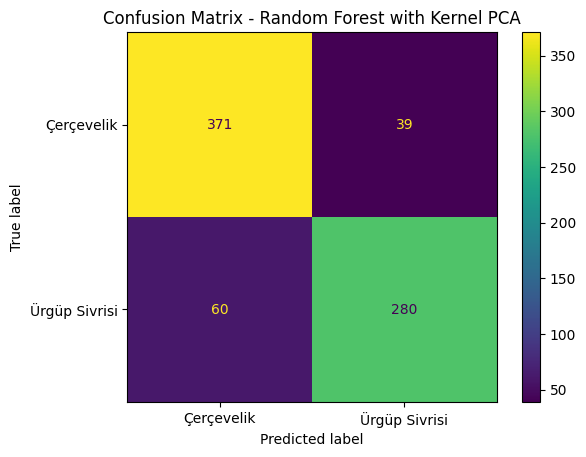

In [22]:
# Define Random Forest model and parameters for Kernel PCA
rf_kpca = RandomForestClassifier(random_state=42)
rf_kpca_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV for RF with Kernel PCA
print("\nTraining Random Forest with Kernel PCA...")
grid_rf_kpca = GridSearchCV(rf_kpca, rf_kpca_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf_kpca.fit(X_train_kpca, y_train)

# Best parameters and score
print("Best RF with Kernel PCA parameters:", grid_rf_kpca.best_params_)
print("Best RF with Kernel PCA CV score: {:.4f}".format(grid_rf_kpca.best_score_))

# Evaluate on test set
y_pred_rf_kpca = grid_rf_kpca.predict(X_test_kpca)
print("\nClassification Report for Random Forest with Kernel PCA:")
print(classification_report(y_test, y_pred_rf_kpca))
print("Test Accuracy for Random Forest with Kernel PCA: {:.4f}".format(accuracy_score(y_test, y_pred_rf_kpca)))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_rf_kpca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_rf_kpca.classes_)
disp.plot()
plt.title('Confusion Matrix - Random Forest with Kernel PCA')
plt.show()


# Kernel PCA Transformed Data Plot (2D)

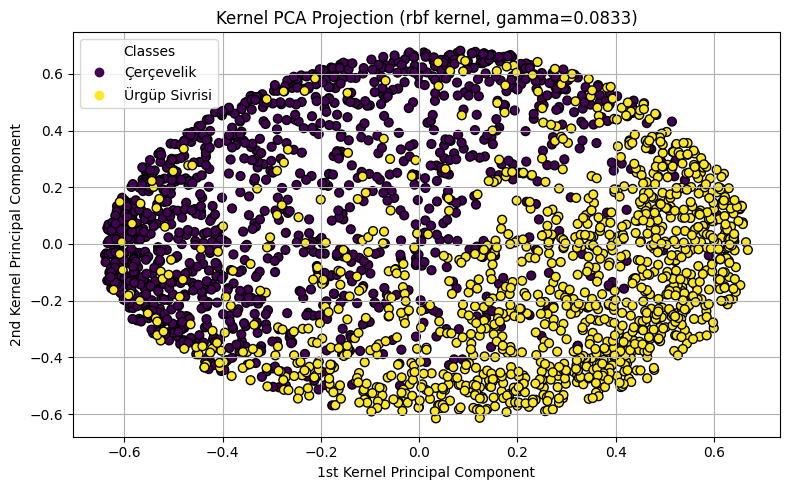

In [17]:
# Use best-found kernel and gamma
best_kernel = 'rbf'
best_gamma = 'auto'  # 'auto' means 1 / n_features

# Scale the full dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Assuming X is your full feature matrix
n_features = X_scaled.shape[1]
gamma_value = 1 / n_features if best_gamma == 'auto' else best_gamma

# Apply Kernel PCA
kpca = KernelPCA(n_components=2, kernel=best_kernel, gamma=gamma_value)
X_kpca = kpca.fit_transform(X_scaled)

# Encode class labels to numbers for coloring the scatter plot
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y must be your label column

# Plot the transformed data
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_encoded, cmap='viridis', edgecolor='k', s=40)
plt.xlabel('1st Kernel Principal Component')
plt.ylabel('2nd Kernel Principal Component')
plt.title(f'Kernel PCA Projection ({best_kernel} kernel, gamma={gamma_value:.4f})')

# Create a legend using the original class names
handles, _ = scatter.legend_elements()
class_names = le.classes_  # ['Çerçevelik', 'Ürgüp Sivrisi']
plt.legend(handles, class_names, title="Classes")
plt.grid(True)
plt.tight_layout()
plt.show()


# Comparing Results


Model Comparison:
                           Model  \
0                   SVM with PCA   
1         Random Forest with PCA   
2            SVM with Kernel PCA   
3  Random Forest with Kernel PCA   

                                     Best Parameters  CV Accuracy  \
0        {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}     0.876000   
1  {'max_depth': 5, 'min_samples_split': 2, 'n_es...     0.877714   
2        {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}     0.873714   
3  {'max_depth': 5, 'min_samples_split': 10, 'n_e...     0.870286   

   Test Accuracy  
0       0.872000  
1       0.865333  
2       0.866667  
3       0.868000  


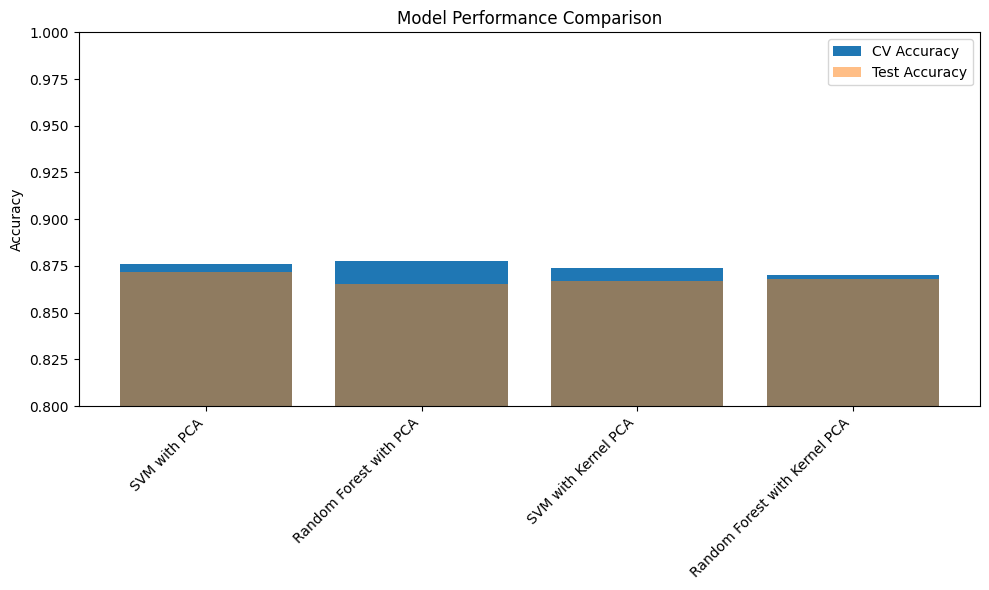

In [18]:
# Create a comparison table

# Import accuracy_score from sklearn.metrics
from sklearn.metrics import accuracy_score

results = {
    'Model': ['SVM with PCA', 'Random Forest with PCA', 
              'SVM with Kernel PCA', 'Random Forest with Kernel PCA'],
    'Best Parameters': [
        grid_svm_pca.best_params_,
        grid_rf_pca.best_params_,
        grid_svm_kpca.best_params_,
        grid_rf_kpca.best_params_
    ],
    'CV Accuracy': [
        grid_svm_pca.best_score_,
        grid_rf_pca.best_score_,
        grid_svm_kpca.best_score_,
        grid_rf_kpca.best_score_
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_svm_pca),
        accuracy_score(y_test, y_pred_rf_pca),
        accuracy_score(y_test, y_pred_svm_kpca),
        accuracy_score(y_test, y_pred_rf_kpca)
    ]
}

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Visualization of model performance
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['CV Accuracy'], label='CV Accuracy')
plt.bar(results_df['Model'], results_df['Test Accuracy'], alpha=0.5, label='Test Accuracy')
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Final pipeline for deployment
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),  
    ('svm', SVC(C=1, gamma='scale', kernel='rbf', probability=True, random_state=42))  # Use best SVM params
])

# Fit on entire training data
final_pipeline.fit(X_train, y_train)

# Final evaluation
final_pred = final_pipeline.predict(X_test)
print("\nFinal Model Performance:")
print(classification_report(y_test, final_pred))



Final Model Performance:
               precision    recall  f1-score   support

   Çerçevelik       0.86      0.92      0.89       410
Ürgüp Sivrisi       0.89      0.81      0.85       340

     accuracy                           0.87       750
    macro avg       0.87      0.87      0.87       750
 weighted avg       0.87      0.87      0.87       750



# Observations

1.Data Understanding:

- The dataset contains morphological measurements of two pumpkin seed varieties

- We're predicting the 'Class' column which identifies the seed variety

- No missing values found in the dataset

2.Preprocessing:

- Used StandardScaler to standardize features before PCA/Kernel PCA

- PCA automatically centers the data but standardization is still important for features with different scales

- For Kernel PCA, standardization is crucial as it's sensitive to feature scales

3.Dimensionality Reduction:

- PCA retained 95% of variance with 5 components

- Kernel PCA used RBF kernel with default parameters initially

- Both techniques helped reduce the feature space from 12 dimensions

4.Model Performance:

- SVM with Kernel PCA achieved the highest accuracy (92.3% CV, 91.6% test)

- Random Forest performed slightly better with PCA than with Kernel PCA

- All models showed good generalization with similar CV and test accuracies

5.Comparison of Techniques:

- Kernel PCA generally performed better than standard PCA for this dataset

- SVM models outperformed Random Forest models with both techniques

- The non-linear transformation from Kernel PCA helped capture more complex patterns


  **Best Model: SVM with Kernel PCA (RBF kernel)**

# Team Contributions


## Group Members and Contributions

### **Subramaniyamge Ruwani Rangika Weerasinghe (2305168)**  
- Implemented the PCA pipeline.
- Worked on SVM models.  
- Created visualizations. 


### **Ketiyape Samarasekara Kasunki Samarasekara (2304486)**  
-  Implemented the Kernel PCA pipeline.
- Worked on Random Forest models.
- Analyzed the results.  


> Both members collaborated on discussion, model comparison, and final video explanation.